## API 기초부터 웹앱/API 서버 구축까지(맛보기)

### 학습 목표

본 차시에서는 학습된 머신러닝 모델을 실제 서비스로 배포하는 방법을 학습함. 구체적인 학습 목표는 다음과 같음:

1. **REST API의 개념과 구조 이해**: HTTP 프로토콜 기반의 웹 통신 방식과 REST(Representational State Transfer) 아키텍처의 핵심 원리를 이해함. 클라이언트-서버 모델에서 자원(Resource)을 어떻게 식별하고 조작하는지 학습함.
2. **Python requests 라이브러리를 활용한 공공데이터 API 호출 실습**: 한국 공공데이터포털의 실제 API를 호출하여 데이터를 수집하고, GET/POST 요청의 차이점과 JSON 데이터 처리 방법을 실습함.
3. **Pre-trained 모델을 활용한 이미지 분류 서비스 구현**: Hugging Face의 사전학습된 이미지 분류 모델을 로드하여 실제 예측 서비스를 구현함. 복잡한 모델 학습 없이 즉시 활용 가능한 AI 서비스를 경험함.
4. **Streamlit을 활용한 대화형 웹 애플리케이션 구현**: Python 코드만으로 이미지 업로드 및 분류 결과를 표시하는 웹앱을 제작함.
5. **FastAPI를 활용한 REST API 서버 구축**: Jupyter Notebook 환경에서 직접 API 서버를 실행하고 테스트함. Pydantic 기반 데이터 검증과 Swagger UI 자동 문서화를 활용함.

### 실습 환경 구성

본 실습을 위해 다음 환경이 필요함:

- **Python 버전**: 3.9 이상
- **필수 라이브러리**: requests, streamlit, fastapi, uvicorn, pydantic, transformers, torch, pillow
- **개발 환경**: Jupyter Notebook
- **인터넷 연결**: 공공데이터 API 호출 및 Pre-trained 모델 다운로드에 필요

In [1]:
# 필수 라이브러리 설치
!pip install requests pandas numpy matplotlib
!pip install streamlit fastapi uvicorn pydantic
!pip install transformers torch torchvision pillow
!pip install nest_asyncio  # Jupyter에서 asyncio 실행을 위한 라이브러리

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---------------------------------------- 12.0/12.0 MB 83.2 MB/s  0:00:00
   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   ---------------------------------------- 566.1/566.1 kB 19.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 77.7 MB/s  0:00:00
   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   -------- ------------------------------ 24.4/110.9 MB 110.6 MB/s eta 0:00:01
   ------------- -------------------------- 37.5/110.9 MB 88.2 MB/s eta 0:00:01
   ---------------------- ----------------- 63.7/110.9 MB 99.1 MB/s eta 0:00:01
   ------------------------------- ------- 88.3/110.9 MB 104.5 MB/s eta 0:00:01
   ---------------------------------- ----- 95.4/110.9 MB 89.6 MB/s eta 0:00:01
   --------------------------------------  110.9/110.9 MB 90.8 MB/s eta 0:00:01
   --------

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [2]:
# 기본 라이브러리 임포트 및 환경 설정
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

# 한글 폰트 설정
import platform
system = platform.system()

if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

print(f"운영체제: {system}")
print(f"Python 버전: {platform.python_version()}")
print(f"현재 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

운영체제: Windows
Python 버전: 3.12.8
현재 시간: 2026-01-19 02:34:13


## 도입: ML 모델 서비스 배포의 필요성

### 모델 학습에서 서비스 배포까지의 여정

머신러닝 프로젝트의 궁극적인 목표는 학습된 모델을 실제 현장에서 활용하는 것임. 

최근에는 **Pre-trained 모델**의 발전으로 복잡한 학습 과정 없이도 고성능 AI 서비스를 즉시 구축할 수 있게 되었음.
> 물론, 도메인 영역에 적합한 전이학습이 필요함. 이러한 부분에 대한 것은, 추후 심화 학습을 참조할 것..

본 차시에서는 다음과 같은 전체 시스템을 구축함:

```
                +---------------------------+
                |    외부 데이터 소스        |
                | (공공데이터 API, 이미지)   |
                +-------------+-------------+
                              |
                              | requests
                              v
                +---------------------------+
                |   Pre-trained 모델        |
                |  (Hugging Face 이미지분류) |
                +-------------+-------------+
                              |
         +--------------------+--------------------+
         |                                         |
         v                                         v
+------------------+                     +------------------+
| Streamlit 웹앱   |                     | FastAPI 서버     |
| (사용자 인터페이스)|                    | (API 엔드포인트)  |
+--------+---------+                     +--------+---------+
         |                                        |
         v                                        v
+------------------+                     +------------------+
| 웹 브라우저      |                     | 외부 시스템      |
| (직접 사용)      |                     | (자동화 연동)    |
+------------------+                     +------------------+
```

### 두 가지 배포 방식의 비교

| 비교 항목 | Streamlit (웹앱) | FastAPI (REST API) |
|:---:|:---|:---|
| **주요 용도** | 사용자 친화적 인터페이스 제공 | 시스템 간 자동화 연동 |
| **호출 방식** | 웹 브라우저에서 직접 접근 | HTTP 요청(GET, POST 등)으로 호출 |
| **대상 사용자** | 사람 (품질 담당자, 엔지니어) | 프로그램 (MES, ERP, 다른 서비스) |
| **출력 형태** | 시각적 웹 페이지 (그래프, 테이블) | JSON 형식의 구조화된 데이터 |
| **대표 사용 사례** | 이미지 업로드 후 분류 결과 확인 | 제조 라인에서 실시간 품질 검사 자동화 |
| **개발 난이도** | 낮음 (Python만으로 완성) | 중간 (API 설계 지식 필요) |

---

## 1. REST API 기초와 공공데이터 API 활용

### 1.1 API(Application Programming Interface)의 개념

#### API란 무엇인가?

**API**는 서로 다른 소프트웨어 시스템 간의 **통신 규약(Protocol)**임. 일상적인 비유로 설명하면, API는 레스토랑의 **웨이터**와 같은 역할을 수행함:

- **고객 (클라이언트)**: 서비스를 요청하는 프로그램
- **웨이터 (API)**: 요청과 응답을 중개하는 인터페이스
- **주방 (서버)**: 실제 작업을 수행하는 시스템

고객은 주방의 내부 구조나 조리 방법을 알 필요가 없음. 웨이터(API)를 통해 **표준화된 방식**으로 주문하면 원하는 결과를 받을 수 있음.

#### 일상 속 API 활용 사례

| 서비스 | API 활용 예시 | 설명 |
|:---|:---|:---|
| 날씨 앱 | 기상청 API | 앱이 기상청 서버에 날씨 데이터를 요청하여 화면에 표시 |
| 지도 서비스 | 네이버/카카오 지도 API | 웹사이트에 지도를 삽입하고 경로 검색 기능 제공 |
| 결제 시스템 | PG사 API | 쇼핑몰이 결제 대행사의 결제 기능을 호출 |
| **AI 서비스** | **이미지 분류 API** | **이미지를 전송하면 분류 결과를 JSON으로 반환** |

### 1.2 REST API의 개념

#### REST(Representational State Transfer)란?

**REST**는 웹에서 **자원(Resource)** 을 다루는 아키텍처 스타일임. Roy Fielding이 2000년 박사 논문에서 제안한 설계 원칙으로, 현재 웹 API의 사실상 표준으로 사용됨.

REST의 핵심 원칙:

1. **자원 기반 (Resource-Based)**: 모든 것을 자원으로 표현하고, 고유한 URL로 식별함
2. **표현을 통한 조작**: 자원의 상태를 JSON, XML 등의 형식으로 표현하여 전송함
3. **무상태 (Stateless)**: 각 요청은 독립적이며, 서버는 클라이언트의 상태를 저장하지 않음
4. **HTTP 메서드 활용**: GET, POST, PUT, DELETE 등 표준 HTTP 메서드로 자원을 조작함

#### HTTP 메서드와 CRUD 연산

| HTTP 메서드 | CRUD 연산 | 설명 | 예시 |
|:---:|:---:|:---|:---|
| **GET** | Read | 자원 조회 (데이터 가져오기) | 날씨 정보 조회, 이미지 목록 조회 |
| **POST** | Create | 새 자원 생성 (데이터 전송) | **이미지 분류 요청**, 새 데이터 등록 |
| **PUT** | Update | 자원 전체 수정 | 설정 업데이트 |
| **DELETE** | Delete | 자원 삭제 | 기록 삭제 |

#### HTTP 상태 코드

| 코드 | 의미 | 설명 | 대응 방법 |
|:---:|:---|:---|:---|
| **200** | OK | 요청 성공 | 정상 처리 |
| **201** | Created | 자원 생성 성공 | 새 데이터 등록 완료 |
| **400** | Bad Request | 잘못된 요청 | 요청 데이터 형식 확인 |
| **401** | Unauthorized | 인증 필요 | API 키 확인 |
| **404** | Not Found | 자원 없음 | URL 경로 확인 |
| **422** | Unprocessable Entity | 검증 실패 | 입력 데이터 값 확인 |
| **500** | Internal Server Error | 서버 오류 | 잠시 후 재시도 |

### 1.3 requests 라이브러리 기초

**requests**는 Python에서 가장 널리 사용되는 HTTP 라이브러리임. 간결한 문법으로 HTTP 요청을 보내고 응답을 처리할 수 있음.

In [3]:
# requests 라이브러리 기본 사용법
import requests

# GET 요청 예시: 공개 테스트 API 호출
# JSONPlaceholder는 테스트용 무료 REST API를 제공하는 서비스임

url = 'https://jsonplaceholder.typicode.com/posts/1'
response = requests.get(url, timeout=10)

print("=" * 60)
print("GET 요청 결과")
print("=" * 60)
print(f"요청 URL: {url}")
print(f"상태 코드: {response.status_code}")
print(f"성공 여부: {response.ok}")
print(f"응답 헤더 (Content-Type): {response.headers.get('Content-Type')}")
print(f"\n응답 본문 (JSON):")
print(json.dumps(response.json(), indent=2))

GET 요청 결과
요청 URL: https://jsonplaceholder.typicode.com/posts/1
상태 코드: 200
성공 여부: True
응답 헤더 (Content-Type): application/json; charset=utf-8

응답 본문 (JSON):
{
  "userId": 1,
  "id": 1,
  "title": "sunt aut facere repellat provident occaecati excepturi optio reprehenderit",
  "body": "quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto"
}


In [4]:
# POST 요청 예시: JSON 데이터 전송
# httpbin.org는 HTTP 요청을 테스트할 수 있는 서비스임

url = 'https://httpbin.org/post'

# 센서 데이터 예시
sensor_data = {
    'temperature': 25.5,
    'humidity': 60,
    'timestamp': datetime.now().isoformat(),
    'location': 'Factory_Line_A'
}

# POST 요청 전송 (json 매개변수 사용)
response = requests.post(url, json=sensor_data, timeout=10)

print("=" * 60)
print("POST 요청 결과")
print("=" * 60)
print(f"상태 코드: {response.status_code}")

# 응답에서 전송된 데이터 확인
result = response.json()
print(f"\n서버가 수신한 JSON 데이터:")
print(json.dumps(result.get('json', {}), indent=2, ensure_ascii=False))

POST 요청 결과
상태 코드: 200

서버가 수신한 JSON 데이터:
{
  "humidity": 60,
  "location": "Factory_Line_A",
  "temperature": 25.5,
  "timestamp": "2026-01-19T02:44:24.716446"
}


### 1.4 한국 공공데이터 API 활용 실습

한국의 공공데이터포털(data.go.kr)은 다양한 공공 API를 제공함. 본 실습에서는 **인증키 없이 사용 가능한 공개 API**를 활용하여 실제 데이터를 수집하는 방법을 학습함.

#### 실습용 공개 API 목록

| API | 설명 | 인증 |
|:---|:---|:---|
| JSONPlaceholder | 테스트용 REST API | 불필요 |
| Open-Meteo | 날씨 예보 API | 불필요 |
| REST Countries | 국가 정보 API | 불필요 |

**참고**: 기상청, 에어코리아 등 한국 공공데이터 API는 공공데이터포털에서 **인증키 발급**이 필요함. 실제 프로젝트에서는 해당 포털에서 회원가입 후 API 키를 발급받아 사용함.

In [5]:
# Open-Meteo API를 활용한 날씨 데이터 수집
# 인증키 불필요, 무료 사용 가능

def get_weather_data(latitude, longitude):
    """
    Open-Meteo API를 사용하여 날씨 데이터를 조회하는 함수
    
    Parameters
    ----------
    latitude : float
        위도
    longitude : float
        경도
    
    Returns
    -------
    dict
        날씨 정보 딕셔너리
    """
    base_url = "https://api.open-meteo.com/v1/forecast"
    
    # API 요청 파라미터
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "current_weather": True,
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m",
        "timezone": "Asia/Seoul"
    }
    
    try:
        response = requests.get(base_url, params=params, timeout=10)
        response.raise_for_status()
        return {"success": True, "data": response.json()}
    except requests.RequestException as e:
        return {"success": False, "error": str(e)}

# 서울 좌표로 날씨 데이터 조회
seoul_lat, seoul_lon = 37.5665, 126.9780
weather_result = get_weather_data(seoul_lat, seoul_lon)

if weather_result["success"]:
    data = weather_result["data"]
    current = data.get("current_weather", {})
    
    print("=" * 60)
    print("서울 현재 날씨 정보 (Open-Meteo API)")
    print("=" * 60)
    print(f"조회 시간: {current.get('time', 'N/A')}")
    print(f"기온: {current.get('temperature', 'N/A')}도")
    print(f"풍속: {current.get('windspeed', 'N/A')} km/h")
    print(f"풍향: {current.get('winddirection', 'N/A')}도")
else:
    print(f"API 호출 실패: {weather_result['error']}")

서울 현재 날씨 정보 (Open-Meteo API)
조회 시간: 2026-01-19T02:30
기온: -0.4도
풍속: 4.4 km/h
풍향: 305도


시간별 날씨 데이터 (처음 5행):
                   시간  기온(도)  습도(%)  풍속(km/h)
0 2026-01-19 00:00:00    0.0     60       2.8
1 2026-01-19 01:00:00   -0.2     66       3.9
2 2026-01-19 02:00:00   -0.3     72       3.4
3 2026-01-19 03:00:00   -0.6     77       5.9
4 2026-01-19 04:00:00   -0.9     78       6.1


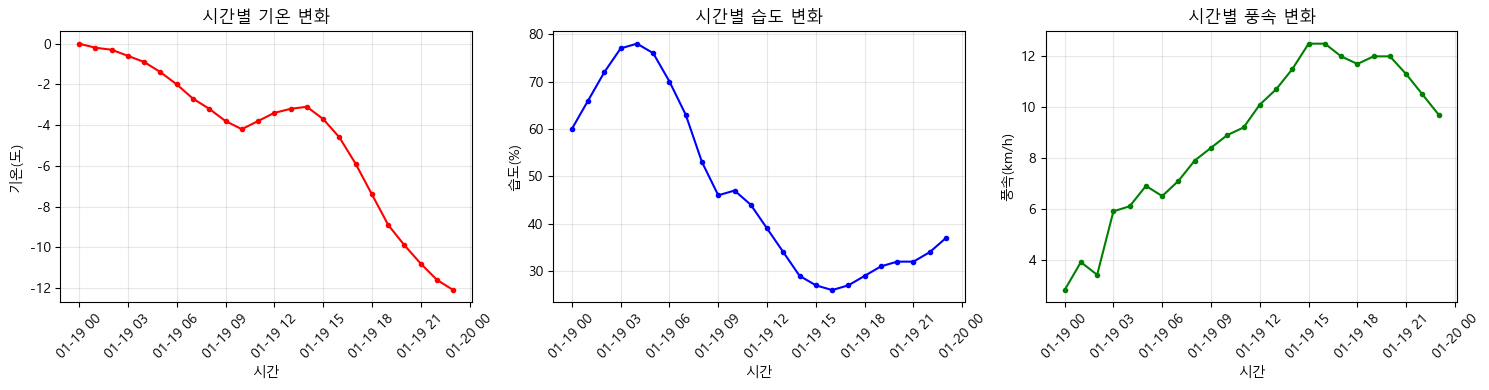

In [6]:
# 시간별 날씨 데이터를 DataFrame으로 변환 및 시각화

if weather_result["success"]:
    hourly = weather_result["data"].get("hourly", {})
    
    # DataFrame 생성
    weather_df = pd.DataFrame({
        '시간': pd.to_datetime(hourly.get('time', []))[:24],  # 24시간만
        '기온(도)': hourly.get('temperature_2m', [])[:24],
        '습도(%)': hourly.get('relative_humidity_2m', [])[:24],
        '풍속(km/h)': hourly.get('wind_speed_10m', [])[:24]
    })
    
    print("시간별 날씨 데이터 (처음 5행):")
    print(weather_df.head())
    
    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 기온
    axes[0].plot(weather_df['시간'], weather_df['기온(도)'], 'r-o', markersize=3)
    axes[0].set_title('시간별 기온 변화')
    axes[0].set_xlabel('시간')
    axes[0].set_ylabel('기온(도)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # 습도
    axes[1].plot(weather_df['시간'], weather_df['습도(%)'], 'b-o', markersize=3)
    axes[1].set_title('시간별 습도 변화')
    axes[1].set_xlabel('시간')
    axes[1].set_ylabel('습도(%)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    # 풍속
    axes[2].plot(weather_df['시간'], weather_df['풍속(km/h)'], 'g-o', markersize=3)
    axes[2].set_title('시간별 풍속 변화')
    axes[2].set_xlabel('시간')
    axes[2].set_ylabel('풍속(km/h)')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 1.5 안전한 API 호출 패턴

API 호출은 네트워크 문제, 서버 오류 등 다양한 이유로 실패할 수 있음. 안정적인 서비스를 위해 적절한 **에러 처리**가 필수임.

In [7]:
# 안전한 API 호출 함수 구현

def safe_api_call(url, method='GET', data=None, params=None, timeout=10, retries=3):
    """
    재시도 로직이 포함된 안전한 API 호출 함수
    
    Parameters
    ----------
    url : str
        API 엔드포인트 URL
    method : str
        HTTP 메서드 ('GET' 또는 'POST')
    data : dict, optional
        POST 요청 시 전송할 JSON 데이터
    params : dict, optional
        쿼리 파라미터
    timeout : int
        요청 제한 시간 (초)
    retries : int
        재시도 횟수
    
    Returns
    -------
    dict
        {'success': bool, 'data': dict 또는 'error': str, 'status_code': int}
    """
    import time
    
    for attempt in range(retries):
        try:
            if method.upper() == 'POST':
                response = requests.post(url, json=data, params=params, timeout=timeout)
            else:
                response = requests.get(url, params=params, timeout=timeout)
            
            response.raise_for_status()
            
            return {
                'success': True,
                'status_code': response.status_code,
                'data': response.json()
            }
        
        except requests.Timeout:
            error_msg = f'요청 시간 초과 ({timeout}초)'
        except requests.ConnectionError:
            error_msg = '서버 연결 실패'
        except requests.HTTPError as e:
            error_msg = f'HTTP 에러: {e.response.status_code}'
        except json.JSONDecodeError:
            error_msg = '응답이 JSON 형식이 아님'
        except Exception as e:
            error_msg = f'예외 발생: {str(e)}'
        
        # 마지막 시도가 아니면 대기 후 재시도
        if attempt < retries - 1:
            wait_time = 2 ** attempt  # 지수 백오프: 1, 2, 4초
            print(f"재시도 {attempt + 1}/{retries - 1}: {wait_time}초 대기...")
            time.sleep(wait_time)
    
    return {
        'success': False,
        'error': error_msg,
        'error_type': 'api_error'
    }

# 테스트
print("정상 요청 테스트:")
result = safe_api_call('https://jsonplaceholder.typicode.com/posts/1')
print(f"  성공 여부: {result['success']}")
if result['success']:
    print(f"  데이터 키: {list(result['data'].keys())}")

print("\n잘못된 URL 테스트:")
result = safe_api_call('https://invalid-domain-test-12345.com', timeout=3, retries=1)
print(f"  성공 여부: {result['success']}")
print(f"  에러: {result.get('error', 'N/A')}")

정상 요청 테스트:
  성공 여부: True
  데이터 키: ['userId', 'id', 'title', 'body']

잘못된 URL 테스트:
  성공 여부: False
  에러: 서버 연결 실패


### 1.6 JSON 데이터 처리

#### JSON(JavaScript Object Notation)이란?

**JSON**은 웹에서 데이터를 교환하기 위한 **경량 텍스트 형식**임. 사람이 읽기 쉽고 기계가 파싱하기 쉬운 구조를 가지고 있어 REST API의 표준 데이터 형식으로 널리 사용됨.

#### Python-JSON 타입 매핑

| Python 타입 | JSON 타입 | 예시 |
|:---|:---|:---|
| `dict` | object | `{"key": "value"}` |
| `list`, `tuple` | array | `[1, 2, 3]` |
| `str` | string | `"hello"` |
| `int`, `float` | number | `42`, `3.14` |
| `True`, `False` | true, false | `true`, `false` |
| `None` | null | `null` |

In [8]:
# JSON 직렬화(Serialization)와 역직렬화(Deserialization)

# 이미지 분류 결과 데이터 (Python dict)
classification_result = {
    'image_id': 'img_001',
    'predictions': [
        {'label': 'cat', 'confidence': 0.92},
        {'label': 'dog', 'confidence': 0.05},
        {'label': 'bird', 'confidence': 0.03}
    ],
    'model_version': '1.0.0',
    'timestamp': datetime.now().isoformat(),
    'is_successful': True,
    'error_message': None
}

# 직렬화: Python dict -> JSON 문자열
json_string = json.dumps(classification_result, indent=2, ensure_ascii=False)
print("=" * 50)
print("직렬화 (Python -> JSON 문자열)")
print("=" * 50)
print(json_string)
print(f"\n타입: {type(json_string)}")

# 역직렬화: JSON 문자열 -> Python dict
print("\n" + "=" * 50)
print("역직렬화 (JSON 문자열 -> Python)")
print("=" * 50)
parsed_data = json.loads(json_string)
print(f"타입: {type(parsed_data)}")
print(f"최상위 예측: {parsed_data['predictions'][0]['label']} ({parsed_data['predictions'][0]['confidence']:.1%})")

직렬화 (Python -> JSON 문자열)
{
  "image_id": "img_001",
  "predictions": [
    {
      "label": "cat",
      "confidence": 0.92
    },
    {
      "label": "dog",
      "confidence": 0.05
    },
    {
      "label": "bird",
      "confidence": 0.03
    }
  ],
  "model_version": "1.0.0",
  "timestamp": "2026-01-19T02:44:44.243316",
  "is_successful": true,
  "error_message": null
}

타입: <class 'str'>

역직렬화 (JSON 문자열 -> Python)
타입: <class 'dict'>
최상위 예측: cat (92.0%)


## 2. Pre-trained 모델과 Streamlit 웹앱

### 2.1 Pre-trained 모델의 개념

**Pre-trained 모델**은 대규모 데이터셋으로 미리 학습된 모델임. 복잡한 학습 과정 없이 즉시 활용하거나, 소량의 데이터로 미세조정(Fine-tuning)하여 사용할 수 있음.

#### Pre-trained 모델의 장점

| 장점 | 설명 |
|:---|:---|
| **즉시 사용 가능** | 별도 학습 없이 바로 예측 서비스 구현 가능 |
| **높은 성능** | 대규모 데이터와 컴퓨팅 자원으로 학습되어 성능 우수 |
| **비용 절감** | GPU 학습 비용 및 시간 절약 |
| **전이 학습** | 소량의 데이터로 미세조정하여 특정 도메인에 적용 가능 |

#### Hugging Face

**Hugging Face**는 머신러닝 모델을 공유하는 플랫폼임. 수만 개의 Pre-trained 모델이 공개되어 있으며, `transformers` 라이브러리를 통해 쉽게 사용할 수 있음.

In [10]:
# Hugging Face transformers 라이브러리를 사용한 이미지 분류
# 사전학습된 모델을 로드하여 즉시 사용
# 단, 현재 기준 Trnasforemer는 Keras 3.0이 아닌 이전 keras를 사용해야 하는 문제가 있을 수 있으므로, 아래 코드 참조
!pip install tf-keras


try:
    from transformers import pipeline
    from PIL import Image
    import io
    
    # 이미지 분류 파이프라인 생성
    # 기본 모델: google/vit-base-patch16-224
    print("이미지 분류 모델 로드 중... (최초 실행 시 모델 다운로드)")
    classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
    print("모델 로드 완료!")
    
    MODEL_LOADED = True
    
except ImportError as e:
    print(f"라이브러리 설치 필요: {e}")
    print("다음 명령어로 설치: pip install transformers torch torchvision pillow")
    MODEL_LOADED = False
except Exception as e:
    print(f"모델 로드 실패: {e}")
    MODEL_LOADED = False

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 46.2 MB/s  0:00:00
이미지 분류 모델 로드 중... (최초 실행 시 모델 다운로드)



Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


모델 로드 완료!


이미지 분류 실행 중...

이미지 분류 결과
1. Persian cat                    78.31% ***********************
2. Egyptian cat                    8.88% **
3. tabby, tabby cat                3.82% *
4. Angora, Angora rabbit           1.63% 
5. lynx, catamount                 1.38% 


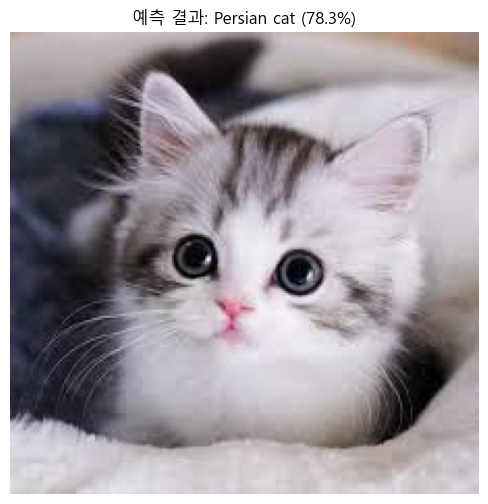

In [13]:
# 인터넷에서 이미지를 가져와 분류 수행

if MODEL_LOADED:
    # 테스트용 이미지 URL (고양이 이미지)
    image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSfIYaUHBYkrxBU6nqG46QJY1DXK9CawuLd-drvoyLOOw&s&ec=121507532"
    
    try:
        # 이미지 다운로드
        response = requests.get(image_url, timeout=10)
        response.raise_for_status()
        
        # PIL Image로 변환
        image = Image.open(io.BytesIO(response.content))
        
        # 이미지 분류 실행
        print("이미지 분류 실행 중...")
        results = classifier(image)
        
        # 결과 출력
        print("\n" + "=" * 60)
        print("이미지 분류 결과")
        print("=" * 60)
        
        for i, result in enumerate(results[:5], 1):
            label = result['label']
            score = result['score']
            bar = '*' * int(score * 30)
            print(f"{i}. {label:30s} {score:6.2%} {bar}")
        
        # 이미지 표시
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.title(f"예측 결과: {results[0]['label']} ({results[0]['score']:.1%})")
        plt.axis('off')
        plt.show()
        
    except Exception as e:
        print(f"이미지 처리 실패: {e}")
else:
    print("모델이 로드되지 않아 분류를 수행할 수 없음")

### 2.2 Streamlit 개요

**Streamlit**은 Python만으로 데이터 애플리케이션을 구축하는 오픈소스 프레임워크임. HTML, CSS, JavaScript 없이 Python 코드만으로 인터랙티브 웹앱을 생성할 수 있음.

#### Streamlit의 특징

| 특징 | 설명 |
|:---|:---|
| **Python 전용** | 웹 개발 지식 없이 Python만으로 앱 구현 가능 |
| **실시간 반응** | 코드 수정 시 자동으로 앱 갱신 |
| **데이터 친화적** | Pandas DataFrame, Matplotlib 등 데이터 라이브러리와 완벽 호환 |
| **배포 용이** | Streamlit Cloud를 통한 무료 배포 지원 |

#### 기본 사용법

```bash
# 설치
pip install streamlit

# 앱 실행 (app.py 파일이 있는 디렉토리에서)
streamlit run app.py

# 브라우저에서 http://localhost:8501 접속
```

### 2.3 Streamlit 핵심 위젯

#### 출력 위젯

| 함수 | 용도 | 예시 |
|:---|:---|:---|
| `st.title()` | 제목 표시 | `st.title("이미지 분류 시스템")` |
| `st.write()` | 범용 출력 | `st.write("텍스트")`, `st.write(df)` |
| `st.image()` | 이미지 표시 | `st.image(image, caption="업로드된 이미지")` |
| `st.dataframe()` | 인터랙티브 테이블 | `st.dataframe(df)` |
| `st.metric()` | KPI 지표 | `st.metric("정확도", "95%", "+2%")` |
| `st.success()` | 성공 메시지 | `st.success("분류 완료!")` |
| `st.error()` | 에러 메시지 | `st.error("파일 형식 오류")` |

#### 입력 위젯

| 함수 | 용도 | 반환 타입 |
|:---|:---|:---|
| `st.button()` | 버튼 | bool |
| `st.file_uploader()` | 파일 업로드 | UploadedFile |
| `st.selectbox()` | 단일 선택 | 선택된 값 |
| `st.slider()` | 범위 선택 | int/float |
| `st.text_input()` | 텍스트 입력 | str |

In [14]:
# Streamlit 이미지 분류 웹앱 코드
# 이 코드를 streamlit_app.py 파일로 저장하여 실행

streamlit_code = '''
# streamlit_app.py
# 실행: streamlit run streamlit_app.py

import streamlit as st
from PIL import Image
import requests
import io

# 페이지 설정
st.set_page_config(
    page_title="이미지 분류 시스템",
    page_icon="",
    layout="wide"
)

st.title("AI 이미지 분류 시스템")
st.markdown("**Hugging Face Pre-trained 모델 기반 실시간 이미지 분류**")
st.markdown("---")

# 모델 로드 (캐싱으로 1회만 로드)
@st.cache_resource
def load_model():
    try:
        from transformers import pipeline
        return pipeline("image-classification", model="google/vit-base-patch16-224")
    except Exception as e:
        st.error(f"모델 로드 실패: {e}")
        return None

# 사이드바: 설정
st.sidebar.title("설정")
top_k = st.sidebar.slider("표시할 예측 수", 1, 10, 5)
confidence_threshold = st.sidebar.slider("신뢰도 임계값", 0.0, 1.0, 0.1)

# 메인 영역
col1, col2 = st.columns(2)

with col1:
    st.subheader("이미지 입력")
    
    # 입력 방식 선택
    input_method = st.radio("입력 방식 선택", ["파일 업로드", "URL 입력"])
    
    image = None
    
    if input_method == "파일 업로드":
        uploaded_file = st.file_uploader(
            "이미지 파일을 업로드하세요",
            type=["jpg", "jpeg", "png", "gif"]
        )
        if uploaded_file is not None:
            image = Image.open(uploaded_file)
    else:
        image_url = st.text_input(
            "이미지 URL을 입력하세요",
            value="https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"
        )
        if image_url:
            try:
                response = requests.get(image_url, timeout=10)
                image = Image.open(io.BytesIO(response.content))
            except:
                st.error("이미지를 불러올 수 없습니다.")
    
    if image is not None:
        st.image(image, caption="입력 이미지", use_container_width=True)

with col2:
    st.subheader("분류 결과")
    
    if image is not None:
        classifier = load_model()
        
        if classifier is not None:
            if st.button("분류 실행", type="primary", use_container_width=True):
                with st.spinner("분류 중..."):
                    results = classifier(image)
                
                st.success("분류 완료!")
                
                # 상위 결과 표시
                for i, result in enumerate(results[:top_k], 1):
                    label = result["label"]
                    score = result["score"]
                    
                    if score >= confidence_threshold:
                        st.metric(
                            label=f"{i}. {label}",
                            value=f"{score:.1%}"
                        )
                        st.progress(score)
                
                # 상세 결과 테이블
                with st.expander("상세 결과 보기"):
                    import pandas as pd
                    df = pd.DataFrame(results[:top_k])
                    df.columns = ["레이블", "신뢰도"]
                    df["신뢰도"] = df["신뢰도"].apply(lambda x: f"{x:.2%}")
                    st.dataframe(df, use_container_width=True)
        else:
            st.warning("모델이 로드되지 않았습니다.")
    else:
        st.info("이미지를 업로드하거나 URL을 입력하세요.")

# 페이지 하단
st.markdown("---")
st.caption("본 시스템은 Hugging Face의 Vision Transformer (ViT) 모델을 사용합니다.")
'''

print("Streamlit 앱 코드:")
print("=" * 60)
print(streamlit_code)

Streamlit 앱 코드:

# streamlit_app.py
# 실행: streamlit run streamlit_app.py

import streamlit as st
from PIL import Image
import requests
import io

# 페이지 설정
st.set_page_config(
    page_title="이미지 분류 시스템",
    page_icon="",
    layout="wide"
)

st.title("AI 이미지 분류 시스템")
st.markdown("**Hugging Face Pre-trained 모델 기반 실시간 이미지 분류**")
st.markdown("---")

# 모델 로드 (캐싱으로 1회만 로드)
@st.cache_resource
def load_model():
    try:
        from transformers import pipeline
        return pipeline("image-classification", model="google/vit-base-patch16-224")
    except Exception as e:
        st.error(f"모델 로드 실패: {e}")
        return None

# 사이드바: 설정
st.sidebar.title("설정")
top_k = st.sidebar.slider("표시할 예측 수", 1, 10, 5)
confidence_threshold = st.sidebar.slider("신뢰도 임계값", 0.0, 1.0, 0.1)

# 메인 영역
col1, col2 = st.columns(2)

with col1:
    st.subheader("이미지 입력")

    # 입력 방식 선택
    input_method = st.radio("입력 방식 선택", ["파일 업로드", "URL 입력"])

    image = None

    if input_method == "파일 업로드":
        uploaded_f

In [15]:
# Streamlit 앱 파일 저장
with open('streamlit_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code.strip())

print("streamlit_app.py 파일이 저장됨")
print("\n실행 방법:")
print("  1. 터미널에서 현재 디렉토리로 이동")
print("  2. streamlit run streamlit_app.py 명령 실행")
print("  3. 브라우저에서 http://localhost:8501 접속")

streamlit_app.py 파일이 저장됨

실행 방법:
  1. 터미널에서 현재 디렉토리로 이동
  2. streamlit run streamlit_app.py 명령 실행
  3. 브라우저에서 http://localhost:8501 접속


## 3. FastAPI 서버 구축

### 3.1 FastAPI 개요

**FastAPI**는 Python 3.7+ 기반의 고성능 웹 프레임워크임. REST API를 구축하여 다른 시스템에서 HTTP 요청으로 모델을 호출할 수 있게 함.

#### FastAPI의 특징

| 특징 | 설명 |
|:---|:---|
| **고성능** | Starlette(비동기 처리)와 Pydantic(데이터 검증) 기반으로 Node.js, Go 수준의 성능 |
| **자동 문서화** | Swagger UI와 ReDoc을 통한 대화형 API 문서 자동 생성 |
| **타입 검증** | Python 타입 힌트 기반 자동 입력 검증 |
| **비동기 지원** | async/await를 통한 비동기 처리 지원 |

### 3.2 Pydantic 데이터 검증

**Pydantic**은 Python 타입 힌트를 활용한 데이터 검증 라이브러리임. FastAPI와 통합되어 API 입력값을 자동으로 검증함.

#### Pydantic의 핵심 개념

$$
\text{입력 데이터} \xrightarrow{\text{Pydantic 검증}} \begin{cases}
\text{검증 성공} \rightarrow \text{정상 처리} \\
\text{검증 실패} \rightarrow \text{422 에러 반환}
\end{cases}
$$

#### Field 검증 옵션

| 옵션 | 의미 | 예시 |
|:---|:---|:---|
| `...` | 필수 필드 (기본값 없음) | `Field(...)` |
| `default` | 기본값 | `Field(default=0.0)` |
| `ge` | 이상 (>=) | `Field(ge=0)` |
| `le` | 이하 (<=) | `Field(le=100)` |
| `min_length` | 최소 문자열 길이 | `Field(min_length=1)` |
| `max_length` | 최대 문자열 길이 | `Field(max_length=50)` |
| `description` | 필드 설명 (API 문서에 표시) | `Field(description="이미지 URL")` |

In [16]:
# Pydantic 모델 정의 예시
from pydantic import BaseModel, Field, field_validator
from typing import List, Optional
from datetime import datetime

# 요청 모델: 이미지 분류 요청
class ImageClassificationRequest(BaseModel):
    """이미지 분류 요청 모델"""
    image_url: str = Field(
        ...,  # 필수 필드
        min_length=10,
        description="분류할 이미지의 URL"
    )
    top_k: int = Field(
        default=5,
        ge=1,
        le=10,
        description="반환할 상위 예측 수"
    )
    threshold: float = Field(
        default=0.1,
        ge=0.0,
        le=1.0,
        description="최소 신뢰도 임계값"
    )
    
    # URL 형식 검증
    @field_validator('image_url')
    @classmethod
    def validate_url(cls, v):
        if not v.startswith(('http://', 'https://')):
            raise ValueError('URL은 http:// 또는 https://로 시작해야 합니다')
        return v
    
    class Config:
        json_schema_extra = {
            "example": {
                "image_url": "https://example.com/cat.jpg",
                "top_k": 5,
                "threshold": 0.1
            }
        }

# 응답 모델: 개별 예측 결과
class PredictionItem(BaseModel):
    """개별 예측 결과"""
    label: str = Field(..., description="예측 레이블")
    confidence: float = Field(..., ge=0, le=1, description="신뢰도 (0~1)")

# 응답 모델: 전체 분류 결과
class ImageClassificationResponse(BaseModel):
    """이미지 분류 응답 모델"""
    success: bool = Field(..., description="처리 성공 여부")
    predictions: List[PredictionItem] = Field(default=[], description="예측 결과 목록")
    top_prediction: Optional[str] = Field(default=None, description="최상위 예측 레이블")
    model_name: str = Field(default="vit-base-patch16-224", description="사용된 모델명")
    timestamp: str = Field(..., description="처리 시간")
    error_message: Optional[str] = Field(default=None, description="에러 메시지")

# 테스트
print("=" * 60)
print("Pydantic 모델 검증 테스트")
print("=" * 60)

# 정상 입력
try:
    valid_request = ImageClassificationRequest(
        image_url="https://example.com/cat.jpg",
        top_k=3,
        threshold=0.2
    )
    print(f"정상 입력: {valid_request.model_dump_json(indent=2)}")
except Exception as e:
    print(f"검증 실패: {e}")

print()

# 잘못된 입력 (URL 형식 오류)
try:
    invalid_request = ImageClassificationRequest(
        image_url="invalid-url",
        top_k=3
    )
except Exception as e:
    print(f"검증 실패 (예상됨): {e}")

Pydantic 모델 검증 테스트
정상 입력: {
  "image_url": "https://example.com/cat.jpg",
  "top_k": 3,
  "threshold": 0.2
}

검증 실패 (예상됨): 1 validation error for ImageClassificationRequest
image_url
  Value error, URL은 http:// 또는 https://로 시작해야 합니다 [type=value_error, input_value='invalid-url', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


### 3.3 Jupyter Notebook에서 FastAPI 실행하기

일반적으로 FastAPI는 별도의 터미널에서 `uvicorn` 명령으로 실행함. 그러나 **nest_asyncio** 라이브러리를 사용하면 Jupyter Notebook 내에서도 FastAPI 서버를 실행하고 테스트할 수 있음.

#### 실행 구조

```
+-------------------+     +-------------------+
| Jupyter Notebook  |     | FastAPI 서버      |
| (이 노트북)        |     | (백그라운드 스레드) |
+--------+----------+     +--------+----------+
         |                         |
         |   requests.post()       |
         +------------------------>|
         |                         |
         |   JSON 응답             |
         |<------------------------+
         |                         |
```

In [17]:
# FastAPI 서버 코드 정의
# Jupyter에서 실행 가능한 형태로 구성

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, field_validator
from typing import List, Optional
from datetime import datetime
import uvicorn
import threading

# FastAPI 앱 생성
app = FastAPI(
    title="이미지 분류 API",
    description="Hugging Face Pre-trained 모델 기반 이미지 분류 서비스",
    version="1.0.0"
)

# CORS 설정
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ===== Pydantic 모델 =====
class ClassificationRequest(BaseModel):
    image_url: str = Field(..., min_length=10, description="이미지 URL")
    top_k: int = Field(default=5, ge=1, le=10, description="상위 예측 수")
    
    @field_validator('image_url')
    @classmethod
    def validate_url(cls, v):
        if not v.startswith(('http://', 'https://')):
            raise ValueError('URL은 http:// 또는 https://로 시작해야 함')
        return v

class PredictionResult(BaseModel):
    label: str
    confidence: float

class ClassificationResponse(BaseModel):
    success: bool
    predictions: List[PredictionResult] = []
    top_label: Optional[str] = None
    timestamp: str
    error: Optional[str] = None

class HealthResponse(BaseModel):
    status: str
    model_loaded: bool
    timestamp: str

# ===== 전역 변수 =====
image_classifier = None

# ===== 엔드포인트 =====
@app.get("/", tags=["기본"])
def root():
    """API 루트 경로"""
    return {
        "service": "이미지 분류 API",
        "version": "1.0.0",
        "docs": "/docs",
        "health": "/health"
    }

@app.get("/health", response_model=HealthResponse, tags=["상태"])
def health_check():
    """서버 및 모델 상태 확인"""
    return HealthResponse(
        status="healthy",
        model_loaded=image_classifier is not None,
        timestamp=datetime.now().isoformat()
    )

@app.post("/classify", response_model=ClassificationResponse, tags=["분류"])
def classify_image(request: ClassificationRequest):
    """
    이미지 URL을 받아 분류 결과를 반환
    
    - **image_url**: 분류할 이미지의 URL
    - **top_k**: 반환할 상위 예측 수 (1-10)
    """
    try:
        # 모델 확인
        if image_classifier is None:
            # 데모용: 모델 없이 더미 결과 반환
            return ClassificationResponse(
                success=True,
                predictions=[
                    PredictionResult(label="demo_cat", confidence=0.85),
                    PredictionResult(label="demo_dog", confidence=0.10),
                    PredictionResult(label="demo_bird", confidence=0.05)
                ],
                top_label="demo_cat",
                timestamp=datetime.now().isoformat()
            )
        
        # 실제 분류 수행 (모델이 로드된 경우)
        from PIL import Image
        import io
        
        response = requests.get(request.image_url, timeout=10)
        response.raise_for_status()
        image = Image.open(io.BytesIO(response.content))
        
        results = image_classifier(image)[:request.top_k]
        
        predictions = [
            PredictionResult(label=r['label'], confidence=round(r['score'], 4))
            for r in results
        ]
        
        return ClassificationResponse(
            success=True,
            predictions=predictions,
            top_label=predictions[0].label if predictions else None,
            timestamp=datetime.now().isoformat()
        )
        
    except Exception as e:
        return ClassificationResponse(
            success=False,
            predictions=[],
            timestamp=datetime.now().isoformat(),
            error=str(e)
        )

print("FastAPI 앱 정의 완료")
print("엔드포인트 목록:")
print("  - GET  /        : API 정보")
print("  - GET  /health  : 상태 확인")
print("  - POST /classify: 이미지 분류")

FastAPI 앱 정의 완료
엔드포인트 목록:
  - GET  /        : API 정보
  - GET  /health  : 상태 확인
  - POST /classify: 이미지 분류


In [18]:
# Jupyter에서 FastAPI 서버 실행
# nest_asyncio를 사용하여 이벤트 루프 중첩 허용

import nest_asyncio
nest_asyncio.apply()

# 서버를 백그라운드 스레드에서 실행
def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")

# 이전에 실행 중인 서버가 있으면 중지 (재실행 시 포트 충돌 방지)
import time

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# 서버 시작 대기
time.sleep(2)

print("FastAPI 서버가 백그라운드에서 실행 중")
print("\n접속 URL:")
print("  - API: http://127.0.0.1:8000")
print("  - Swagger UI (자동 문서): http://127.0.0.1:8000/docs")
print("  - ReDoc: http://127.0.0.1:8000/redoc")

FastAPI 서버가 백그라운드에서 실행 중

접속 URL:
  - API: http://127.0.0.1:8000
  - Swagger UI (자동 문서): http://127.0.0.1:8000/docs
  - ReDoc: http://127.0.0.1:8000/redoc


### 3.4 API 테스트

서버가 실행 중인 상태에서 requests를 사용하여 API를 테스트함.

In [19]:
# API 테스트 1: 헬스 체크
import requests

BASE_URL = "http://127.0.0.1:8000"

print("=" * 60)
print("API 테스트 1: 헬스 체크 (GET /health)")
print("=" * 60)

try:
    response = requests.get(f"{BASE_URL}/health", timeout=5)
    print(f"상태 코드: {response.status_code}")
    print(f"응답:\n{json.dumps(response.json(), indent=2, ensure_ascii=False)}")
except Exception as e:
    print(f"요청 실패: {e}")

API 테스트 1: 헬스 체크 (GET /health)
상태 코드: 200
응답:
{
  "status": "healthy",
  "model_loaded": false,
  "timestamp": "2026-01-19T02:47:37.649569"
}


In [20]:
# API 테스트 2: 이미지 분류 (정상 요청)
print("=" * 60)
print("API 테스트 2: 이미지 분류 (POST /classify)")
print("=" * 60)

request_data = {
    "image_url": "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg",
    "top_k": 5
}

print(f"요청 데이터: {json.dumps(request_data, indent=2)}")

try:
    response = requests.post(
        f"{BASE_URL}/classify",
        json=request_data,
        timeout=30
    )
    print(f"\n상태 코드: {response.status_code}")
    print(f"응답:\n{json.dumps(response.json(), indent=2, ensure_ascii=False)}")
except Exception as e:
    print(f"요청 실패: {e}")

API 테스트 2: 이미지 분류 (POST /classify)
요청 데이터: {
  "image_url": "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg",
  "top_k": 5
}

상태 코드: 200
응답:
{
  "success": true,
  "predictions": [
    {
      "label": "demo_cat",
      "confidence": 0.85
    },
    {
      "label": "demo_dog",
      "confidence": 0.1
    },
    {
      "label": "demo_bird",
      "confidence": 0.05
    }
  ],
  "top_label": "demo_cat",
  "timestamp": "2026-01-19T02:47:39.244279",
  "error": null
}


In [21]:
# API 테스트 3: 잘못된 입력 (검증 실패 테스트)
print("=" * 60)
print("API 테스트 3: 잘못된 입력 (검증 실패 예상)")
print("=" * 60)

invalid_request = {
    "image_url": "not-a-valid-url",  # URL 형식 오류
    "top_k": 5
}

print(f"요청 데이터: {json.dumps(invalid_request, indent=2)}")

try:
    response = requests.post(
        f"{BASE_URL}/classify",
        json=invalid_request,
        timeout=10
    )
    print(f"\n상태 코드: {response.status_code}")
    print(f"응답:\n{json.dumps(response.json(), indent=2, ensure_ascii=False)}")
except Exception as e:
    print(f"요청 실패: {e}")

API 테스트 3: 잘못된 입력 (검증 실패 예상)
요청 데이터: {
  "image_url": "not-a-valid-url",
  "top_k": 5
}

상태 코드: 422
응답:
{
  "detail": [
    {
      "type": "value_error",
      "loc": [
        "body",
        "image_url"
      ],
      "msg": "Value error, URL은 http:// 또는 https://로 시작해야 함",
      "input": "not-a-valid-url",
      "ctx": {
        "error": {}
      }
    }
  ]
}


### 3.5 Swagger UI 자동 문서화

FastAPI는 **Swagger UI**를 통해 자동으로 API 문서를 생성함. `/docs` 경로에서 확인할 수 있음.

브라우저에서 http://127.0.0.1:8000/docs 에 접속하면 다음 기능을 사용할 수 있음:

1. **API 엔드포인트 목록**: 모든 엔드포인트와 HTTP 메서드 확인
2. **요청/응답 스키마**: Pydantic 모델에서 자동 생성된 JSON 스키마
3. **Try it out**: 브라우저에서 직접 API 테스트
4. **코드 예시**: curl, Python 등 다양한 언어의 호출 예시

In [22]:
# Swagger UI에서 생성된 OpenAPI 스키마 확인
print("=" * 60)
print("OpenAPI 스키마 조회")
print("=" * 60)

try:
    response = requests.get(f"{BASE_URL}/openapi.json", timeout=5)
    schema = response.json()
    
    print(f"API 제목: {schema['info']['title']}")
    print(f"버전: {schema['info']['version']}")
    print(f"\n등록된 엔드포인트:")
    for path, methods in schema['paths'].items():
        for method, details in methods.items():
            summary = details.get('summary', 'N/A')
            print(f"  {method.upper():6s} {path:15s} - {summary}")
except Exception as e:
    print(f"스키마 조회 실패: {e}")

OpenAPI 스키마 조회
API 제목: 이미지 분류 API
버전: 1.0.0

등록된 엔드포인트:
  GET    /               - Root
  GET    /health         - Health Check
  POST   /classify       - Classify Image


### 3.6 FastAPI 서버 코드 파일 저장

실제 배포를 위해 FastAPI 서버 코드를 별도 파일로 저장함.

In [23]:
# FastAPI 서버 코드를 파일로 저장
fastapi_code = '''
# fastapi_server.py
# 실행: uvicorn fastapi_server:app --reload

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, field_validator
from typing import List, Optional
from datetime import datetime
import requests

# FastAPI 앱 생성
app = FastAPI(
    title="이미지 분류 API",
    description="""
    Hugging Face Pre-trained 모델 기반 이미지 분류 서비스
    
    ## 기능
    - 이미지 URL을 입력받아 분류 결과 반환
    - 상위 K개 예측 결과 제공
    - 자동 입력 검증 및 에러 처리
    """,
    version="1.0.0",
    contact={
        "name": "API Support",
        "email": "support@example.com"
    }
)

# CORS 설정
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ===== Pydantic 모델 =====
class ClassificationRequest(BaseModel):
    """이미지 분류 요청 모델"""
    image_url: str = Field(
        ...,
        min_length=10,
        description="분류할 이미지의 URL",
        json_schema_extra={"example": "https://example.com/cat.jpg"}
    )
    top_k: int = Field(
        default=5,
        ge=1,
        le=10,
        description="반환할 상위 예측 수 (1-10)"
    )
    
    @field_validator("image_url")
    @classmethod
    def validate_url(cls, v):
        if not v.startswith(("http://", "https://")):
            raise ValueError("URL은 http:// 또는 https://로 시작해야 합니다")
        return v

class PredictionResult(BaseModel):
    """개별 예측 결과"""
    label: str = Field(..., description="예측 레이블")
    confidence: float = Field(..., ge=0, le=1, description="신뢰도")

class ClassificationResponse(BaseModel):
    """분류 응답 모델"""
    success: bool = Field(..., description="처리 성공 여부")
    predictions: List[PredictionResult] = Field(default=[], description="예측 결과 목록")
    top_label: Optional[str] = Field(default=None, description="최상위 예측")
    model_name: str = Field(default="vit-base-patch16-224", description="모델명")
    timestamp: str = Field(..., description="처리 시간")
    error: Optional[str] = Field(default=None, description="에러 메시지")

class HealthResponse(BaseModel):
    """헬스 체크 응답"""
    status: str
    model_loaded: bool
    timestamp: str

# ===== 모델 로드 =====
classifier = None

@app.on_event("startup")
async def load_model():
    global classifier
    try:
        from transformers import pipeline
        classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
        print("모델 로드 완료")
    except Exception as e:
        print(f"모델 로드 실패: {e}")

# ===== 엔드포인트 =====
@app.get("/", tags=["기본"])
def root():
    """API 정보 반환"""
    return {
        "service": "이미지 분류 API",
        "version": "1.0.0",
        "docs": "/docs"
    }

@app.get("/health", response_model=HealthResponse, tags=["상태"])
def health_check():
    """서버 및 모델 상태 확인"""
    return HealthResponse(
        status="healthy",
        model_loaded=classifier is not None,
        timestamp=datetime.now().isoformat()
    )

@app.post("/classify", response_model=ClassificationResponse, tags=["분류"])
def classify_image(request: ClassificationRequest):
    """
    이미지 URL을 받아 분류 결과를 반환합니다.
    
    - **image_url**: 분류할 이미지의 URL (http:// 또는 https://로 시작)
    - **top_k**: 반환할 상위 예측 수 (기본값: 5)
    """
    try:
        if classifier is None:
            raise HTTPException(status_code=503, detail="모델이 로드되지 않았습니다")
        
        from PIL import Image
        import io
        
        # 이미지 다운로드
        response = requests.get(request.image_url, timeout=10)
        response.raise_for_status()
        image = Image.open(io.BytesIO(response.content))
        
        # 분류 수행
        results = classifier(image)[:request.top_k]
        
        predictions = [
            PredictionResult(label=r["label"], confidence=round(r["score"], 4))
            for r in results
        ]
        
        return ClassificationResponse(
            success=True,
            predictions=predictions,
            top_label=predictions[0].label if predictions else None,
            timestamp=datetime.now().isoformat()
        )
        
    except HTTPException:
        raise
    except Exception as e:
        return ClassificationResponse(
            success=False,
            predictions=[],
            timestamp=datetime.now().isoformat(),
            error=str(e)
        )

if __name__ == "__main__":
    import uvicorn
    uvicorn.run("fastapi_server:app", host="0.0.0.0", port=8000, reload=True)
'''

with open('fastapi_server.py', 'w', encoding='utf-8') as f:
    f.write(fastapi_code.strip())

print("fastapi_server.py 파일이 저장됨")
print("\n실행 방법:")
print("  1. 터미널에서 현재 디렉토리로 이동")
print("  2. uvicorn fastapi_server:app --reload 명령 실행")
print("  3. 브라우저에서 http://localhost:8000/docs 접속")

fastapi_server.py 파일이 저장됨

실행 방법:
  1. 터미널에서 현재 디렉토리로 이동
  2. uvicorn fastapi_server:app --reload 명령 실행
  3. 브라우저에서 http://localhost:8000/docs 접속


---

## 핵심 정리

### 기술별 비교 요약

| 구분 | requests | Streamlit | FastAPI |
|:---|:---|:---|:---|
| **역할** | API 클라이언트 | 웹 UI 서버 | API 서버 |
| **설치** | `pip install requests` | `pip install streamlit` | `pip install fastapi uvicorn` |
| **실행** | Python 스크립트 내 | `streamlit run app.py` | `uvicorn main:app` |
| **기본 포트** | - | 8501 | 8000 |
| **입력 방식** | `json=` 매개변수 | 위젯 (파일업로드, 버튼) | JSON 요청 본문 |
| **출력 형식** | `response.json()` | 웹 페이지 | JSON 응답 |
| **주 사용자** | 개발자 | 최종 사용자 | 시스템/개발자 |

### 핵심 코드 패턴

```python
# requests - API 호출
response = requests.post(url, json=data, timeout=10)
if response.ok:
    result = response.json()

# Streamlit - 웹앱
@st.cache_resource
def load_model():
    return pipeline("image-classification")

uploaded_file = st.file_uploader("이미지 업로드")
if st.button("분류"):
    result = model(image)

# FastAPI - API 서버
class Request(BaseModel):
    image_url: str = Field(..., min_length=10)

@app.post("/classify", response_model=Response)
def classify(request: Request):
    return classifier(request.image_url)
```

## 학습 체크리스트

본 차시 학습 완료 후 다음 항목을 점검함:

| 구분 | 항목 | 확인 |
|:---|:---|:---:|
| **API 기초** | REST API의 개념과 특징을 설명할 수 있음 | |
| **API 기초** | HTTP 메서드(GET, POST)의 용도를 구분할 수 있음 | |
| **API 기초** | HTTP 상태 코드의 의미를 파악할 수 있음 | |
| **requests** | `requests.get()`, `requests.post()` 함수를 사용할 수 있음 | |
| **requests** | JSON 데이터를 전송하고 응답을 파싱할 수 있음 | |
| **requests** | 공공데이터 API를 호출하여 데이터를 수집할 수 있음 | |
| **Pre-trained** | Hugging Face 모델을 로드하여 사용할 수 있음 | |
| **Streamlit** | 파일 업로드 기능이 있는 웹앱을 만들 수 있음 | |
| **Streamlit** | `@st.cache_resource`로 모델을 캐싱할 수 있음 | |
| **FastAPI** | Pydantic 모델로 요청/응답 데이터를 정의할 수 있음 | |
| **FastAPI** | POST 엔드포인트를 구현할 수 있음 | |
| **FastAPI** | Swagger UI(/docs)에서 API를 테스트할 수 있음 | |